In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
df = pd.read_csv("../dataset/tuyona_gold_mult_prod_synthetic.csv")
df.head()

,возраст,пол,семейное положение,количество иждивенцев,профессия,статус клиента,зарплата,сумма кредита,ежемесячное погашение по графику,активные кредиты,первоначальный взнос,наличие карты,филиал,название продукта,is_bad_client
0,35.000000,female,замужем,2.239248,savdogar,активный,6.096211e+06,8476201,140226,1,0,нет,turkiston,кулон,1
1,37.325250,female,замужем,1.903685,usta quruvchi,активный,7.151897e+05,940907,516693,1,41191,да,navoiy,кулон,0
2,20.197133,female,замужем,2.040779,nafaqa,активный,6.146950e+06,940907,523905,1,40064,нет,turkiston,кулон,0
3,48.760520,male,замужем,1.814498,nafaqa,активный,3.654538e+04,1906455,1036331,1,43814,нет,turkiston,комплект,0
4,49.527639,female,замужем,2.518625,malyar usta,активный,0.000000e+00,7646401,554311,0,52648,да,turkiston,кулон; кулон,0


In [3]:
df.columns = df.columns.str.strip().str.lower()

In [4]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [5]:
df.dtypes

возраст                             float64
пол                                  object
семейное положение                   object
количество иждивенцев               float64
профессия                            object
статус клиента                       object
зарплата                            float64
сумма кредита                         int64
ежемесячное погашение по графику      int64
активные кредиты                      int64
первоначальный взнос                  int64
наличие карты                        object
филиал                               object
название продукта                    object
is_bad_client                         int64
dtype: object

In [6]:
df['is_bad_client'].value_counts()

0    6000
1    4000
Name: is_bad_client, dtype: int64

In [7]:
npl_ratio = df["is_bad_client"].mean() * 100
print(f"NPL: {npl_ratio:.2f}%")

NPL: 40.00%


In [8]:
df.isna().sum()

возраст                             0
пол                                 0
семейное положение                  0
количество иждивенцев               0
профессия                           0
статус клиента                      0
зарплата                            0
сумма кредита                       0
ежемесячное погашение по графику    0
активные кредиты                    0
первоначальный взнос                0
наличие карты                       0
филиал                              0
название продукта                   0
is_bad_client                       0
dtype: int64

In [9]:
feature_cols = [
    'возраст', 'пол', 'семейное положение', 'количество иждивенцев',
    'профессия', 'статус клиента', 'зарплата', 'сумма кредита',
    'ежемесячное погашение по графику', 'активные кредиты',
    'первоначальный взнос', 'наличие карты', 'филиал', 'название продукта'
]

In [10]:
target_col = 'is_bad_client'

In [11]:
col_map = {
    'возраст': 'age',
    'пол': 'gender',
    'семейное положение': 'marital_status',
    'количество иждивенцев': 'dependents',
    'профессия': 'occupation',
    'статус клиента': 'customer_status',
    'зарплата': 'salary',
    'сумма кредита': 'loan_amount',
    'ежемесячное погашение по графику': 'monthly_payment',
    'активные кредиты': 'active_loans',
    'первоначальный взнос': 'down_payment',
    'наличие карты': 'has_card',
    'филиал': 'branch',
    'название продукта': 'product_name'
}

In [12]:
categorical_cols = [
    'gender', 'marital_status', 'occupation',
    'customer_status', 'has_card', 'branch', 'product_name'
]

In [13]:
df = df.rename(columns=col_map)

In [14]:
df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,35.000000,female,замужем,2.239248,savdogar,активный,6.096211e+06,8476201,140226,1,0,нет,turkiston,кулон,1
1,37.325250,female,замужем,1.903685,usta quruvchi,активный,7.151897e+05,940907,516693,1,41191,да,navoiy,кулон,0
2,20.197133,female,замужем,2.040779,nafaqa,активный,6.146950e+06,940907,523905,1,40064,нет,turkiston,кулон,0
3,48.760520,male,замужем,1.814498,nafaqa,активный,3.654538e+04,1906455,1036331,1,43814,нет,turkiston,комплект,0
4,49.527639,female,замужем,2.518625,malyar usta,активный,0.000000e+00,7646401,554311,0,52648,да,turkiston,кулон; кулон,0


In [15]:
marital_status_mapping = {
    'женат': 'married',
    'не замужем': 'single',
    'замужем': 'married',
    'холост': 'single'
}
df['marital_status'] = df['marital_status'].replace(marital_status_mapping)

In [16]:
df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,35.000000,female,married,2.239248,savdogar,активный,6.096211e+06,8476201,140226,1,0,нет,turkiston,кулон,1
1,37.325250,female,married,1.903685,usta quruvchi,активный,7.151897e+05,940907,516693,1,41191,да,navoiy,кулон,0
2,20.197133,female,married,2.040779,nafaqa,активный,6.146950e+06,940907,523905,1,40064,нет,turkiston,кулон,0
3,48.760520,male,married,1.814498,nafaqa,активный,3.654538e+04,1906455,1036331,1,43814,нет,turkiston,комплект,0
4,49.527639,female,married,2.518625,malyar usta,активный,0.000000e+00,7646401,554311,0,52648,да,turkiston,кулон; кулон,0


In [17]:
customer_status_mapping = {
    'активный': 'active',
}
df['customer_status'] = df['customer_status'].replace(customer_status_mapping)

In [18]:
df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,35.000000,female,married,2.239248,savdogar,active,6.096211e+06,8476201,140226,1,0,нет,turkiston,кулон,1
1,37.325250,female,married,1.903685,usta quruvchi,active,7.151897e+05,940907,516693,1,41191,да,navoiy,кулон,0
2,20.197133,female,married,2.040779,nafaqa,active,6.146950e+06,940907,523905,1,40064,нет,turkiston,кулон,0
3,48.760520,male,married,1.814498,nafaqa,active,3.654538e+04,1906455,1036331,1,43814,нет,turkiston,комплект,0
4,49.527639,female,married,2.518625,malyar usta,active,0.000000e+00,7646401,554311,0,52648,да,turkiston,кулон; кулон,0


In [19]:
has_card_mapping = {
    'да': 'yes',
    'нет': 'no'
}
df['has_card'] = df['has_card'].replace(has_card_mapping)

In [20]:
def replace_product_name(name: str):
    if not isinstance(name, str) or name.strip() == "":
        return "ring"

    parts = [part.strip() for part in name.split(";") if part.strip()]

    def map_single(n: str):
        first = n[0:3].lower()
        if first in ["кул"]:
            return "pendant"
        elif first in ["ком"]:
            return "set"
        elif first in ["кол"]:
            return "ring"
        elif first in ["цеп"]:
            return "chain"
        elif first in ["сер"]:
            return "earrings"
        else:
            return "pendant"
        
    return "; ".join(map(map_single, parts))


In [21]:
# product_name_mapping = {
#     'кулон': 'pendant',
#     'комплект': 'set',
#     'кольцо': 'ring',
#     'цепочка': 'chain',
#     'серьги': 'earrings'
# }
# df['product_name'] = df['product_name'].replace(product_name_mapping)
df["product_name"] = df["product_name"].apply(replace_product_name)

df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,35.000000,female,married,2.239248,savdogar,active,6.096211e+06,8476201,140226,1,0,no,turkiston,pendant,1
1,37.325250,female,married,1.903685,usta quruvchi,active,7.151897e+05,940907,516693,1,41191,yes,navoiy,pendant,0
2,20.197133,female,married,2.040779,nafaqa,active,6.146950e+06,940907,523905,1,40064,no,turkiston,pendant,0
3,48.760520,male,married,1.814498,nafaqa,active,3.654538e+04,1906455,1036331,1,43814,no,turkiston,set,0
4,49.527639,female,married,2.518625,malyar usta,active,0.000000e+00,7646401,554311,0,52648,yes,turkiston,pendant; pendant,0


In [22]:
for col in df.select_dtypes(exclude=['object']).columns:
    df[col] = df[col].round()
df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,35.0,female,married,2.0,savdogar,active,6096211.0,8476201,140226,1,0,no,turkiston,pendant,1
1,37.0,female,married,2.0,usta quruvchi,active,715190.0,940907,516693,1,41191,yes,navoiy,pendant,0
2,20.0,female,married,2.0,nafaqa,active,6146950.0,940907,523905,1,40064,no,turkiston,pendant,0
3,49.0,male,married,2.0,nafaqa,active,36545.0,1906455,1036331,1,43814,no,turkiston,set,0
4,50.0,female,married,3.0,malyar usta,active,0.0,7646401,554311,0,52648,yes,turkiston,pendant; pendant,0


In [23]:
df['product_name'].value_counts()

pendant                               4605
set                                   3045
pendant; pendant                       798
ring                                   405
set; pendant                           190
pendant; set                           183
ring; pendant                          148
pendant; ring                          139
chain; pendant                          92
ring; pendant; pendant; pendant         92
chain                                   74
pendant; pendant; pendant               58
earrings                                33
pendant; pendant; pendant; pendant      21
chain; pendant; pendant                 21
ring; pendant; pendant                  21
set; pendant; pendant                   19
set; pendant; ring                      17
pendant; set; pendant                   16
ring; ring                              13
pendant; chain                          10
Name: product_name, dtype: int64

In [24]:
def deduplicate_cell(value: str) -> str:
    if not isinstance(value, str) or value.strip() == "":
        return value

    seen = set()
    unique_parts = []
    for part in [p.strip() for p in value.split(";") if p.strip()]:
        if part not in seen:
            seen.add(part)
            unique_parts.append(part)
    return "; ".join(unique_parts)


In [25]:
df["product_name"] = df["product_name"].apply(deduplicate_cell)
df['product_name'].value_counts()

pendant               5482
set                   3045
ring                   418
ring; pendant          261
set; pendant           209
pendant; set           199
pendant; ring          139
chain; pendant         113
chain                   74
earrings                33
set; pendant; ring      17
pendant; chain          10
Name: product_name, dtype: int64

In [26]:
y = df["is_bad_client"]
X = df.drop(columns=["is_bad_client"])

In [27]:
feature_cols = [
    'age', 
    'gender', 
    'marital_status', 
    'dependents',
    'occupation', 
    'customer_status', 
    'salary', 
    'loan_amount',
    'monthly_payment', 
    'active_loans',
    'down_payment', 
    'has_card', 
    'branch', 
    'product_name'
]

In [28]:
feature_cols

['age',
 'gender',
 'marital_status',
 'dependents',
 'occupation',
 'customer_status',
 'salary',
 'loan_amount',
 'monthly_payment',
 'active_loans',
 'down_payment',
 'has_card',
 'branch',
 'product_name']

In [29]:
multi_value_cols = ['product_name']
single_cat_cols = ['gender', 'marital_status', 'occupation', 'customer_status', 'has_card', 'branch'] 
numeric_cols = ['age', 'dependents', 'salary', 'loan_amount', 'monthly_payment', 'active_loans', 'down_payment']

In [30]:
import numpy as np

In [31]:
class MultiValueSplitter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        def split_value(x):
            if isinstance(x, str):
                return x.split(';')
            elif pd.isna(x):
                return ['missing']
            else:
                return x  # In case input is already a list
        # Return a list of lists, no reshaping
        return [split_value(x) for x in X.ravel()]

In [32]:
class SafeMultiLabelBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self

    def transform(self, X):
        cleaned = [[label for label in row if label in self.mlb.classes_] for row in X]
        X_trans = self.mlb.transform(cleaned)
        return pd.DataFrame(X_trans, columns=self.mlb.classes_)

In [33]:
df.head()

,age,gender,marital_status,dependents,occupation,customer_status,salary,loan_amount,monthly_payment,active_loans,down_payment,has_card,branch,product_name,is_bad_client
0,35.0,female,married,2.0,savdogar,active,6096211.0,8476201,140226,1,0,no,turkiston,pendant,1
1,37.0,female,married,2.0,usta quruvchi,active,715190.0,940907,516693,1,41191,yes,navoiy,pendant,0
2,20.0,female,married,2.0,nafaqa,active,6146950.0,940907,523905,1,40064,no,turkiston,pendant,0
3,49.0,male,married,2.0,nafaqa,active,36545.0,1906455,1036331,1,43814,no,turkiston,set,0
4,50.0,female,married,3.0,malyar usta,active,0.0,7646401,554311,0,52648,yes,turkiston,pendant,0


In [34]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [35]:
single_cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

In [36]:
multi_cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("splitter", MultiValueSplitter()),
    ("mlb", SafeMultiLabelBinarizer())
])

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("single_cat", single_cat_transformer, single_cat_cols),
        ("multi_cat", multi_cat_transformer, multi_value_cols)
    ]
)

In [38]:
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'dependents',
                                                   'salary', 'loan_amount',
                                                   'monthly_payment',
                                                   'active_loans',
                                                   'down_payment']),
                                                 ('single_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   One...
                                                  ['gender', 'marital_status',
                                                   'occupation',
                                                   'customer_status',
                                                   'has_card', 'branch']),
                                                 ('multi_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('splitter',
                                                                   MultiValueSplitter()),
                                                                  ('mlb',
                                                                   SafeMultiLabelBinarizer())]),
                                                  ['product_name'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [46]:
print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))

/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Train accuracy: 0.999875
Test accuracy: 0.944


/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [47]:
y_pred = clf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1200
           1       0.94      0.92      0.93       800

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000

Confusion Matrix:
[[1150   50]
 [  62  738]]


/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 500],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__max_features": ["sqrt", "log2", None]
}

In [49]:
grid_search = GridSearchCV(
    clf, param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   1.9s


/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.3s


...

/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END classifier__max_depth=None, classifier__max_features=None, classifier__min_samples_split=10, classifier__n_estimators=500; total time= 1.2min


/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


[CV] END classifier__max_depth=None, classifier__max_features=None, classifier__min_samples_split=10, classifier__n_estimators=500; total time= 1.1min


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'dependents',
                                                                          'salary',
                                                                          'loan_amount',
                                                                          'monthly_payment',
                                                                          'active_loans',
                                                                          'down_payment']),
                                                                        ('single_cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='mo...
                                                                                          SafeMultiLabelBinarizer())]),
                                                                         ['product_name'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, 20, None],
                         'classifier__max_features': ['sqrt', 'log2', None],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 500]},
             scoring='f1', verbose=2)

In [50]:
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best params: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}
Best CV score: 0.9275383296909617


In [51]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [52]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1200
           1       0.94      0.93      0.93       800

    accuracy                           0.95      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.95      0.95      0.95      2000

[[1150   50]
 [  59  741]]


In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np


# feature_names = grid_search.best_estimator_["preprocessor"].get_feature_names_out()
# importances = grid_search.best_estimator_["classifier"].feature_importances_

# indices = np.argsort(importances)[::-1]
# plt.figure(figsize=(10, 6))
# plt.bar(range(20), importances[indices][:20])
# plt.xticks(range(20), feature_names[indices][:20], rotation=90)
# plt.title("Top 20 Feature Importances")
# plt.show()


AttributeError: Estimator splitter does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?

In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report

def find_best_threshold_balanced(model, X_valid, y_valid, beta=1.0, grid_size=201, f1_tol=0.01,
                                 min_precision=None, min_recall=None):
 
    y_proba = model.predict_proba(X_valid)[:, 1]
    thresholds = np.linspace(0.0, 1.0, grid_size)

    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        prec = precision_score(y_valid, y_pred, zero_division=0) * 100
        rec  = recall_score(y_valid, y_pred, zero_division=0) * 100
        f1   = f1_score(y_valid, y_pred, zero_division=0) * 100
        fbet = fbeta_score(y_valid, y_pred, beta=beta, zero_division=0) * 100
        
        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
        npl = (fn / (tp + fn) * 100) if (tp + fn) > 0 else np.nan
        acc = ((tp + tn) / (tp + tn + fp + fn)) * 100

        rows.append((t*100, prec, rec, f1, fbet, acc, abs(prec - rec), npl))

    metrics_df = pd.DataFrame(
        rows,
        columns=["threshold", "precision", "recall", "f1", "f_beta", "accuracy", "prec_recall_gap", "npl"]
    )

    cand = metrics_df.copy()
    if min_precision is not None:
        cand = cand[cand["precision"] >= min_precision * 100]
    if min_recall is not None:
        cand = cand[cand["recall"] >= min_recall * 100]
    if cand.empty:
        cand = metrics_df 


    max_f1 = cand["f1"].max() if beta == 1.0 else cand["f_beta"].max()
    score_col = "f1" if beta == 1.0 else "f_beta"

    near_opt = cand[cand[score_col] >= max_f1 * (1 - f1_tol)]

    best_row = near_opt.sort_values(
        ["prec_recall_gap", score_col, "threshold"],
        ascending=[True, False, True]
    ).iloc[0]
    best_threshold = float(best_row["threshold"])
    return best_threshold, metrics_df, best_row


In [55]:
best_model = grid_search.best_estimator_

best_thr, metrics_table, best_metrics = find_best_threshold_balanced(
    best_model, X_test, y_test,
    beta=1.0,
    grid_size=401,
    f1_tol=0.01
)

print(f"Лучший порог: {best_thr:.3f}")
print("Метрики на лучшем пороге:")
print(best_metrics)

/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Лучший порог: 48.250
Метрики на лучшем пороге:
threshold          48.250000
precision          93.008739
recall             93.125000
f1                 93.066833
f_beta             93.066833
accuracy           94.450000
prec_recall_gap     0.116261
npl                 6.875000
Name: 193, dtype: float64


In [56]:
best_thr = best_thr / 100 

In [57]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_opt = (y_proba >= best_thr).astype(int)

print("\nClassification report @ optimal threshold:")
print(classification_report(y_test, y_pred_opt, digits=3))
print("Confusion matrix @ optimal threshold:")
print(confusion_matrix(y_test, y_pred_opt))

print("\nTop 10 порогов по F1 + баланс precision/recall + NPL:")
print(
    metrics_table.sort_values(["f1", "prec_recall_gap"], ascending=[False, True])
                 .head(10)
                 .round(3)
)


/home/jasurkhon/.local/share/virtualenvs/moliyai_credit_scoring-rRHq_Gak/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Classification report @ optimal threshold:
              precision    recall  f1-score   support

           0      0.954     0.953     0.954      1200
           1      0.930     0.931     0.931       800

    accuracy                          0.945      2000
   macro avg      0.942     0.942     0.942      2000
weighted avg      0.945     0.945     0.945      2000

Confusion matrix @ optimal threshold:
[[1144   56]
 [  55  745]]

Top 10 порогов по F1 + баланс precision/recall + NPL:
     threshold  precision  recall      f1  f_beta  accuracy  prec_recall_gap  \
180      45.00     91.879  94.750  93.292  93.292     94.55            2.871   
181      45.25     92.083  94.500  93.276  93.276     94.55            2.417   
182      45.50     92.083  94.500  93.276  93.276     94.55            2.417   
177      44.25     91.667  94.875  93.243  93.243     94.50            3.208   
178      44.50     91.768  94.750  93.235  93.235     94.50            2.982   
179      44.75     91.768  94

In [58]:
metrics_table.to_csv("tuyona_gold_mult_prod_metrics_table.csv", index=False)

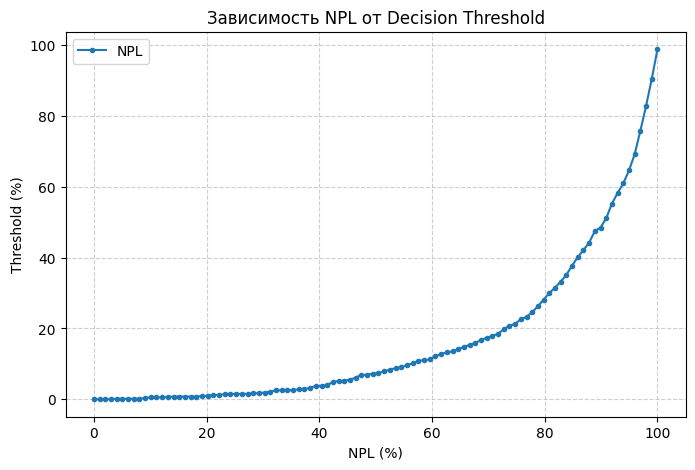

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def npl_at_thresholds(y_true, y_proba, thresholds):
    npl_scores = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        # NPL = FN / (TP + FN)
        if (tp + fn) > 0:
            npl = fn / (tp + fn)
        else:
            npl = np.nan
        npl_scores.append(npl)
    return npl_scores


thresholds = np.linspace(0, 1, 100)
npl_values = npl_at_thresholds(y_test, y_proba, thresholds)

plt.figure(figsize=(8,5))
plt.plot(thresholds * 100, np.array(npl_values) * 100, marker="o", markersize=3, label="NPL")
plt.xlabel("NPL (%)")
plt.ylabel("Threshold (%)")
plt.title("Зависимость NPL от Decision Threshold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


In [60]:
import pickle
with open("../model/tuyona_gold_rf_model_v2.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [61]:
import cloudpickle
with open("../model/tuyona_gold_rf_model_v2.1.pkl", "wb") as f:
    cloudpickle.dump(clf, f)
